## Week7_Census API

## Learning goals
After today's lesson you should be able to:
- Get Census data from the U.S. Census API
- Use the Socrata API


Today's lesson is borrowed from: 
- Prof.Wenfei Xu's materials from Spring 2023
- [PyGIS - Open Source Spatial Programming and Remote Sensing book](https://pygis.io/docs/d_access_census.html)
- [The Socrata SODA API documentation](https://dev.socrata.com/consumers/getting-started.html)

In [33]:
## You might need to run these or manually add the libraries to your environment in Anaconda
!pip install census
!pip install us

In [2]:
# We are going to start importing the libraries we need
# all in one cell. 
# It is a good practice to keep all the imports in one cell so that
# we can easily see what libraries we are using in the notebook.
import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns


# we use the inline backend to generate the plots within the browser
%matplotlib inline

# import Census - a wrapper for the U.S. Census Bureau API
from census import Census
# states object allows access to standardized information about U.S. states
from us import states



# 0. Census Data: Census survey and statistical boundaries

## 0.1 Census Surveys
The United States Census Bureau has been collecting information on its residents in the country since 1790 through surveys sent by mail (since 2020, you can submit your survey by phone, mail, or online). Census data is used for a variety of governmental purposes including: provision of housing, infrastructure, and public amenities; making districting decisions for schools, precints, and elections; and more generally, to understand the population, socio-economic, and demographic characteristics of residents in the country. 

The US Census has historically been taken every 10 years. Every household in the U.S. is sent a Census survey (and you are legally required to respond.) In 2005, the Census Bureau created the American Community Survey (ACS), which is collected every month on a sample of households.

**Question:** What is the difference between a census and a survey?  

Since 2020, the Census only contains 10 questions (historically called the "short form census") such as age, sex, race, Hispanic origin, and owner/renter status. The ACS contains a larger set of questions such as employment, education, transportation.

Because the ACS is more frequent, it is often used for more current census needs; however, because it is also a sample, we generally need a longer time span to get a robust sample. This is why we will often use the **5-yr ACS** (for ex: 2012 - 2016 ACS) to represent the year (here, 2014).

Census data is often the baseline survey dataset in the area of urban planning because it provides racial, socio-economic, housing, etc. information that is often the highlight or backdrop of a study.

## 0.2 Census Geographies
There are different, often nested Census geographic regions used for  different administrative scales. The most commonly used regions are statistical areas, typically nested within each other, whose boundaries are defined by certain physical, administrative, and population constraints. For instance, a **Census block** is bounded by physical features such as streets and administrative boundaries such as city limits and school districts. **Block groups**, the smallest unit of analysis that is still mostly statistically robust, are collections of Census blocks (hence the name) that generally have between 800 to 5000 people. **Census tracts** generally have between 1000 and 8000 people. [Here's more information](https://pitt.libguides.com/uscensus/understandinggeography) about Census geographies if you're curious.

See the image below for how these regions nest within one another.

<img src="https://raw.githubusercontent.com/wenzhengli-etal/UrbanDataScience_4680_5680/main/img/geography_illustration.png" alt="drawing" width="500" style="display: block; margin: 0 auto"/>

## 0.3 [Social Explorer](https://www-socialexplorer-com.proxy.library.cornell.edu/ezproxy)
This is a great tool for looking at Census and ACS data visually. Social Explorer cleans and organizes Census and ACS datasets, making them easier to use. They also have datasets beyond just Census Bureau data. You can also output images and shareable links to the map. I encourage you to sign up (through Cornell it's free) and explore this tool on your own time.


## 0.4 What is an API 
APIs are tools that allow different software applications to communicate with one another. In particular, the Census API allows us to access data from the US Census Bureau.

# 1. U.S. Census 
The Census makes data publicly available directly from their website `census.gov`. They have a bunch of APIs on their website that allow you to access various datasets: 
</figure>
<img src="https://raw.githubusercontent.com/wenzhengli-etal/UrbanDataScience_4680_5680/main/img/census_API.png" alt="drawing" width="700" style="display: block; margin: 0 auto"/>
</figure>




## 1.1 Census Python Package
The [census](https://pypi.org/project/census/) python library is a wrapper for the US Census API. We are also going to use a helper tool called [us](https://pypi.org/project/us/)， a complementary library, that helps us to navigate the FIPS codes and other US State metadata like capitals, time zones, postal codes, etc. 


In [35]:
# retrieves the FIPS code for Virginia using the us library.
states.VA.fips

'51'

In [36]:
# how about NY? 
states.NY.fips

'36'

In [37]:
# get the state capital (seat) of NYS
states.NY.capital

'Albany'

You will need to create and keep track of your Census API key, which can be obtained [here](http://api.census.gov/data/key_signup.html). It will take a while for you to get the email with the API key. 

In [3]:
# Set API key
c = Census("YOUR CENSUS API KEY HERE")


In [39]:
c = Census("66b0e853a8bb0a804fd0011841548d361197252f")


## 1.2 Getting the ACS 5-year


#### Let us now finish a task: 
We want to know the `percentage of seniors aged 65 and older` for each `census tract` in `NYS` based on the ACS-5 year tables. To obtain this indicator, we need to know the `total population` and the `number of people aged 65 and older`. Let's see how we can retrieve the two variables by calling the API.

#### Let us look at which function in the Census library we can use.

There are various geographies at which we can get the ACS 5-year tables, here are the functions and inputs: 

* state(fields, state_fips)
* state_county(fields, state_fips, county_fips)
* state_county_blockgroup(fields, state_fips, county_fips, blockgroup)
* state_county_subdivision(fields, state_fips, county_fips, subdiv_fips)
* ``state_county_tract(fields, state_fips, county_fips, tract)``
* state_place(fields, state_fips, place)
* state_congressional_district(fields, state_fips, congressional_district)
* state_legislative_district_upper(fields, state_fips, legislative_district)
* state_legislative_district_lower(fields, state_fips, legislative_district)
* us(fields)
* state_zipcode(fields, state_fips, zip5)

You can consult the [documentation](https://pypi.org/project/census/) of the `census` library to see which vintages the library has. It looks like they only have up to the 2022 5YR (2018-2022). 


#### Next, Let’s see how to navigate to the correct data column/table.

Going on the [ACS 5Yr page on the census website](https://www.census.gov/data/developers/data-sets/acs-5year.html) (make sure to select the correct year!), we can see the different types of tables that exist. 

| Data Type                      | Purpose                                      | Smallest Available Geography |
|--------------------------------|----------------------------------------------|------------------------------|
| **Detailed Tables**            | Most detailed topic-specific data           | Block Group                 |
| **Subject Tables**             | Summary of a specific ACS topic             | Census Tract                |
| **Data Profiles**              | Broad social, economic, housing, and demographic data | Census Tract                |
| **Comparison Profiles**        | Comparison of current 5-year data vs. past 5-year data | County, Place, County Subdivisions |



Let us first look at the detailed `Detailed Tables` to see if they offer us what we want. 

We can check out all table/columns from the "[Detailed Tables](https://api.census.gov/data/2022/acs/acs5/variables.html)". As we can see here, there are so many detailed tables, and sometimes it can be difficult to find the table we need. Therefore, we need to understand the classification code of these Tables to quickly locate the major class of the required variables. Here is the [Table IDs explained page](https://www.census.gov/programs-surveys/acs/data/data-tables/table-ids-explained.html). Based on the Table, the detailed tables are all begin with "B" or "C", and the class denotes age is 01. So, let us look at tables start with `B01`. 

<div style="background-color:#d4edda; padding:10px; border-radius:5px;">

✅ **Note:**  
We can also use the [Table Shells and Table List](https://www.census.gov/programs-surveys/acs/technical-documentation/table-shells.2022.html#list-tab-79594641) to more quickly look for the columns we need.
- Table shells contain the line number, description of the data, and table ID.  
- "The ACS table list contains columns with the table IDs, table titles, table universes, and 1-year/5-year availability for all Detailed Tables, Supplemental Estimate Tables, Comparison Profiles, Data Profiles, and Subject Tables in one spreadsheet."  

You will have to download the `[YEAR] ACS Detailed Table Shells` for the ACS 1/5 YR if you want to use the table shells.  

</div>




Well, the age categories are very detailed in the Detailed Tables, but what we need is the aggregated data -- so, let us collect multiple variables and aggregate them. 
- ✅ Note:   The suffix "E" represents estimate value. If the suffix is "M", it represents the margin of error.

In [40]:
# S0101_C01_030E: the total population aged 65 and older
# S0101_C01_001E: total population
ny_census = c.acs5.state_county_tract(fields = ('NAME', 
                                          'B01001_001E', 
                                          "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
                                          "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",
                                          ), # Retrieve: population>64, total population
                                      state_fips = states.NY.fips,
                                      county_fips = "*", # Select all counties in NY
                                      tract = "*",
                                      year = 2019) # ACS 5 year 2019 - 2015

Okay, now we successfully get the data, let us explore the dataset a bit. 

In [42]:
# ny_census

In [44]:
# convert the ny_census list to a dataframe, called df_ny
df_ny = pd.DataFrame(ny_census)
df_ny.head()

,NAME,B01001_001E,B01001_020E,B01001_021E,B01001_022E,B01001_023E,B01001_024E,B01001_025E,B01001_044E,B01001_045E,B01001_046E,B01001_047E,B01001_048E,B01001_049E,state,county,tract
0,"Census Tract 55, Onondaga County, New York",3563.0,25.0,31.0,29.0,0.0,6.0,12.0,21.0,18.0,40.0,28.0,8.0,20.0,36,067,005500
1,"Census Tract 56.01, Onondaga County, New York",1599.0,42.0,9.0,44.0,7.0,6.0,6.0,25.0,24.0,48.0,19.0,6.0,15.0,36,067,005601
2,"Census Tract 61.02, Onondaga County, New York",1842.0,55.0,59.0,19.0,11.0,25.0,37.0,39.0,20.0,120.0,110.0,83.0,68.0,36,067,006102
3,"Census Tract 112.01, Onondaga County, New York",3844.0,54.0,71.0,46.0,53.0,0.0,6.0,37.0,65.0,62.0,45.0,6.0,7.0,36,067,011201
4,"Census Tract 56.02, Onondaga County, New York",3950.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36,067,005602


In [45]:
df_ny.shape

(4918, 17)

We do need to create a `GEOID` column that's the actual FIPS code. 

In [46]:
# get unique tract identifier in New York (GEOID )
df_ny["GEOID"] = df_ny["state"] + df_ny["county"] + df_ny["tract"]

In [48]:
df_ny.head(3)

,NAME,B01001_001E,B01001_020E,B01001_021E,B01001_022E,B01001_023E,B01001_024E,B01001_025E,B01001_044E,B01001_045E,B01001_046E,B01001_047E,B01001_048E,B01001_049E,state,county,tract,GEOID
0,"Census Tract 55, Onondaga County, New York",3563.0,25.0,31.0,29.0,0.0,6.0,12.0,21.0,18.0,40.0,28.0,8.0,20.0,36,067,005500,36067005500
1,"Census Tract 56.01, Onondaga County, New York",1599.0,42.0,9.0,44.0,7.0,6.0,6.0,25.0,24.0,48.0,19.0,6.0,15.0,36,067,005601,36067005601
2,"Census Tract 61.02, Onondaga County, New York",1842.0,55.0,59.0,19.0,11.0,25.0,37.0,39.0,20.0,120.0,110.0,83.0,68.0,36,067,006102,36067006102


We calculate the percentage of population who are 64 and older.

In [49]:
# generate total number of people who are 64 and older.
df_ny["senior_pop"] = df_ny.loc[ : , "B01001_020E": "B01001_049E" ].sum(axis = 1)

In [22]:
# drop the unused columns
df_ny = df_ny.drop(columns=df_ny.loc[:, "B01001_020E":"B01001_049E"].columns)

In [50]:
# calculate the rate of aging people
df_ny["senior_pop_rate"] = df_ny["senior_pop"] / df_ny["B01001_001E"]

In [51]:
df_ny.head(3)

,NAME,B01001_001E,B01001_020E,B01001_021E,B01001_022E,B01001_023E,B01001_024E,B01001_025E,B01001_044E,B01001_045E,B01001_046E,B01001_047E,B01001_048E,B01001_049E,state,county,tract,GEOID,senior_pop,senior_pop_rate
0,"Census Tract 55, Onondaga County, New York",3563.0,25.0,31.0,29.0,0.0,6.0,12.0,21.0,18.0,40.0,28.0,8.0,20.0,36,067,005500,36067005500,238.0,0.066798
1,"Census Tract 56.01, Onondaga County, New York",1599.0,42.0,9.0,44.0,7.0,6.0,6.0,25.0,24.0,48.0,19.0,6.0,15.0,36,067,005601,36067005601,251.0,0.156973
2,"Census Tract 61.02, Onondaga County, New York",1842.0,55.0,59.0,19.0,11.0,25.0,37.0,39.0,20.0,120.0,110.0,83.0,68.0,36,067,006102,36067006102,646.0,0.350706


## 1.3 Get the shapefiles 
- The Census also maintains a [set of shapefiles](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html) (TIGER/Line) that has the geometries by state, counties, tracts, block groups, and more. 

- When you go to the Tiger/Line Shapefiles, make sure to select the year you are looking for: 
</figure>
<img src="https://raw.githubusercontent.com/wenzhengli-etal/UrbanDataScience_4680_5680/main/img/tigerline.png" alt="drawing" width="800" style="display: block; margin: 0 auto"/>
</figure>

You can use the **FTP Archive** to find the particular boundary and state you need (you'll have to know the FIPS code for the state):

</figure>
<img src="https://raw.githubusercontent.com/wenzhengli-etal/UrbanDataScience_4680_5680/main/img/tracts.png" alt="drawing" width="600" style="display: block; margin: 0 auto"/>
</figure>


Once you have all this information, you can read the shapefile directly from the URL link: 

In [52]:
# read the NYS census tract boundary in 2019
gdf_tract = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2019/TRACT/tl_2019_36_tract.zip")

In [54]:
gdf_tract.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,36,081,044800,36081044800,448,Census Tract 448,G5020,S,208002,0,+40.7110219,-073.8026344,"POLYGON ((-73.80646 40.71206, -73.80556 40.712..."
1,36,081,045800,36081045800,458,Census Tract 458,G5020,S,245281,0,+40.7152626,-073.7909261,"POLYGON ((-73.79364 40.71382, -73.79362 40.713..."
2,36,081,046200,36081046200,462,Census Tract 462,G5020,S,249611,0,+40.7098547,-073.7879749,"POLYGON ((-73.79203 40.71107, -73.79101 40.711..."
3,36,081,046300,36081046300,463,Census Tract 463,G5020,S,159415,0,+40.7440007,-073.8710900,"POLYGON ((-73.87468 40.74335, -73.87423 40.743..."
4,36,081,046400,36081046400,464,Census Tract 464,G5020,S,228767,0,+40.7168637,-073.7869958,"POLYGON ((-73.79187 40.71379, -73.79085 40.714..."


In [57]:
# check if the row number match
print(df_ny.shape)
print(gdf_tract.shape)

(4918, 20)
(4918, 13)


Finally, we can merge the tables we created with the shapefile

In [58]:
# gdf.merge()
gdf_tract_senior = gdf_tract.merge(df_ny, left_on = 'GEOID', right_on = 'GEOID')

<Axes: >

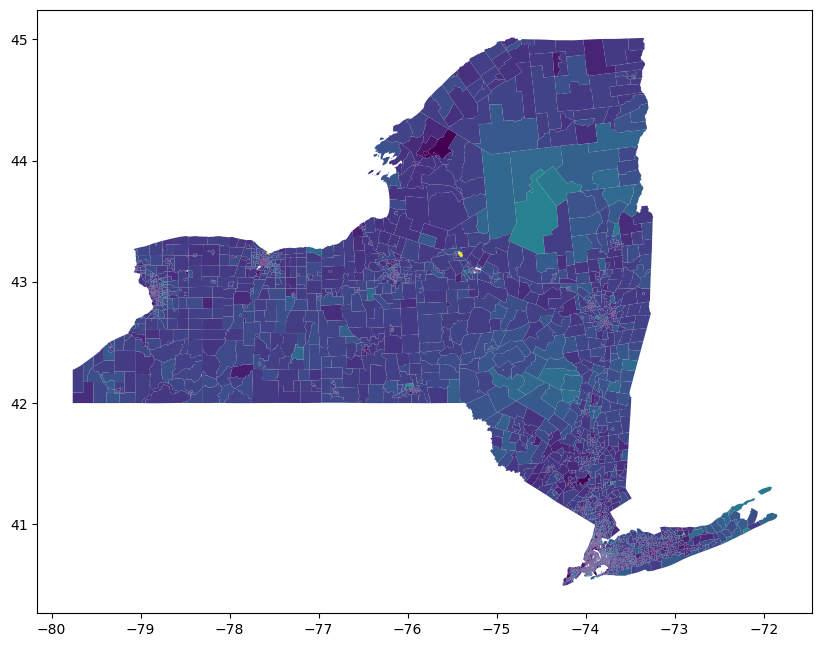

In [59]:
# plot the new gdf
gdf_tract_senior.plot('senior_pop_rate', figsize = (10,10))

## in-class exercise: Q1
Using the [ACS table](https://www.census.gov/programs-surveys/acs/technical-documentation/table-shells.2019.html#list-tab-LO1F1MU1CQP3YOHD2T) lookup page to download "2019 ACS Detailed Table Shells"
- Find the table ID (in the format of "B00000") for the **HISPANIC OR LATINO ORIGIN BY RACE** table 
- Plot the percentage Hispanic or Latino Origin by Race for Oregon using the method we described above. 


In [ ]:
### INSERT YOUR CODE HERE
or_census_geo = 

In [ ]:
fig, ax = plt.subplots(figsize=(15,15))

or_census_geo.plot(### INSERT YOUR CODE HERE)
ax.set_axis_off()

## Use tight_layout to remove the white space around the plot
plt.tight_layout()

# save your figure
fig.savefig('OR_perc_hispanic.png')   # save the figure to file

## 2. Socrata and Socrata APIs
Many government open data portals were built by the same company, Socrata (acquired a few years back by Tyler Technologies), which created the infrastructure and front-end interface to access open government data. See for example, [NYC](https://opendata.cityofnewyork.us/), [Chicago Data Portal](https://chicago.socrata.com/), [Los Angeles](https://data.lacity.org/), [Seattle](https://data.seattle.gov/)

We are going to look at **Mandatory Inclusionary Housing zones (MIH)** in New York City [click here](https://data.cityofnewyork.us/City-Government/Mandatory-Inclusionary-Housing/m79g-k9r4/about_data). Mandatory Inclusionary Housing zones are designated areas where developers are required to include a percentage of affordable housing units in new residential projects in exchange for zoning benefits or increased density.


You may have noticed that, when we go to export data, that there is a **API** section. Click to expand the **API** section.

</figure>
<img src="https://raw.githubusercontent.com/wenzhengli-etal/UrbanDataScience_4680_5680/main/img/MIH.png" alt="drawing" width="800" style="display: block; margin: 0 auto"/>
</figure>



SODA is Socrata's API for allowing users to building tools and applications to access open-portal data. This is most useful when you have to programmatically connect your data export to something else. For instance, if you're running a website that needs to update data in real-time or if you don't want to download an updated dataset each time, you can connect your notebook or app to this API. 

 
**choose `json` data format and Copy the API endpoint URL**. 
- `json` means: "JavaScript Object Notation". it is a text-based file format that stores data using key-value pairs. json is commonly used to exchange data between web applications and servers due to its simplicity and language-independent nature.
- API endpoint URL: think about it a web address that you can use to get data, just like opening a website, but it returns structured data (like JSON).

## 2.1 API endpoint to GeoDataFrame

We can pretty easily convert this JSON file into a geodataframe. A JSON stands for "JavaScript Object Notation" and is a file format that was designed for the JavaScript language, but is easily translated to other formats that we know well. 

The good thing is that pandas has a `pd.read_json()` function that will allow us read this JSON as a DF and eventually turn it into a geodataframe. 

In [5]:
# read the data using pd.read_json
df_mih = pd.read_json('https://data.cityofnewyork.us/resource/m79g-k9r4.json')
df_mih.head(3)

,the_geom,boro,status,project_nam,date_adopte,zr_ulurpno,zr_map,cd,mih_option,zoning_map,project_id,shape_leng,shape_area
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-7...",3.0,Adopted,587 Bergen Street Rezoning,2018-01-31T00:00:00.000,170357ZRK,CD8-Map 2 (Area 1),8,Option 1,16C,P2014K0056,994.864292,24194.095354
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-7...",2.0,Adopted,Lambert Houses Redevelopment Master Plan,2016-11-29T00:00:00.000,160288ZRX,CD6-Map 6 (Area 1),6,Option 1 and Deep Affordability Option,3D,P2013X0120,5871.253136,700002.648777
2,"{'type': 'MultiPolygon', 'coordinates': [[[[-7...",3.0,Adopted,Caton Flats,2017-04-25T00:00:00.000,170129ZRK,CD14-Map 2 (Area 1),14,Option 2,16D,P2015K0157,881.625234,46239.338435


Notice that there is a **the_geom** column that looks like it might have geometry information. 

In [62]:
## check out the first element of the_geom
df_mih.the_geom.head(1)[0]

{'type': 'MultiPolygon',
 'coordinates': [[[[-73.97005234444579, 40.68021608113781],
    [-73.9701745086798, 40.679837393437204],
    [-73.97051343622893, 40.6799083638831],
    [-73.97048439558766, 40.67998907404539],
    [-73.9704485841527, 40.680088501453326],
    [-73.97040680033422, 40.68020389883599],
    [-73.97056179168806, 40.68023498832951],
    [-73.97070595850158, 40.680266695313115],
    [-73.97080802811533, 40.68028821563118],
    [-73.97067126466236, 40.68066556930235],
    [-73.97064088704784, 40.680749387731346],
    [-73.97046687384798, 40.68071292820161],
    [-73.97050034337454, 40.68062983462443],
    [-73.97060760975816, 40.68033217454737],
    [-73.97052764226544, 40.68031545495396],
    [-73.97017707781549, 40.680242160012405],
    [-73.97016048020541, 40.68023868962951],
    [-73.97005234444579, 40.68021608113781]]]]}

We are going to turn these dictionaries (key-value pairs), into Shapely geometries, which is the only piece of our data that is missing so we can turn this into a geometry. 

In [10]:
from shapely.geometry import shape

`shape` function is used to convert a GeoJSON-like dictionary (which contains geometric data) into a Shapely geometry object (e.g., Point, LineString, or Polygon).

In [24]:
## the apply method applies the function to each row of the dataframe
df_mih['geometry'] = df_mih['the_geom'].apply(shape) 

## I'm going to use the GeoDataFrame method to create a GeoDataFrame
## I figured the CRS is 4326 looking at the lat/longs in the geometries.
## We can look at the shapefile .prj file to see what the CRS is.
gdf_mih = gpd.GeoDataFrame(df_mih,geometry='geometry',crs='epsg:4326')

In [26]:
gdf_mih.head()

,the_geom,boro,status,project_nam,date_adopte,zr_ulurpno,zr_map,cd,mih_option,zoning_map,project_id,shape_leng,shape_area,geometry
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-7...",3.0,Adopted,587 Bergen Street Rezoning,2018-01-31T00:00:00.000,170357ZRK,CD8-Map 2 (Area 1),8,Option 1,16C,P2014K0056,994.864292,24194.095354,"MULTIPOLYGON (((-73.97005 40.68022, -73.97017 ..."
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-7...",2.0,Adopted,Lambert Houses Redevelopment Master Plan,2016-11-29T00:00:00.000,160288ZRX,CD6-Map 6 (Area 1),6,Option 1 and Deep Affordability Option,3D,P2013X0120,5871.253136,700002.648777,"MULTIPOLYGON (((-73.87734 40.84399, -73.87817 ..."
2,"{'type': 'MultiPolygon', 'coordinates': [[[[-7...",3.0,Adopted,Caton Flats,2017-04-25T00:00:00.000,170129ZRK,CD14-Map 2 (Area 1),14,Option 2,16D,P2015K0157,881.625234,46239.338435,"MULTIPOLYGON (((-73.95934 40.65298, -73.95988 ..."
3,"{'type': 'MultiPolygon', 'coordinates': [[[[-7...",2.0,Adopted,1932 Bryant Avenue,2016-11-29T00:00:00.000,160366ZRX,CD6-Map 7 (Area 2),6,Option 1 and Option 2,3D,P2014X0534,1568.622702,96628.576787,"MULTIPOLYGON (((-73.88122 40.84014, -73.88099 ..."
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-7...",1.0,Adopted,Lexington Gardens II,2016-11-29T00:00:00.000,160337ZRM,CD11-Map 1 (Area 1),11,Option 1,6B,P2014M0548,1549.849292,134693.552208,"MULTIPOLYGON (((-73.94532 40.79355, -73.94578 ..."


Geopandas has a function called `explore()` that allows us to make a quick interactive map within the jupyter notebook. 
- This tool is built with using some geopandas functionality paired with a library called `folium`, which is itself a wrapper for a front-end javascript library used to make interactive maps for a browser called `leaflet.js`. 
- `wrapper` refers to the package (here `Folium`) that provides a simplified interface to another library, often written in a different language - in this case the `leaflet.js` written in JavaScript).

In [60]:
## Faint, but these are our buildings
# gdf_mih.explore()

## 2.2 Filtering
The SODA API allows us to filter data from the endpoint url (the json link we used to import the mih data). 

Why might we want to do this? there are very large datasets such as the [311 Service Requests dataset](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9) (with 39 million rows) or the [Open Parking and Camera Violations](https://data.cityofnewyork.us/City-Government/Open-Parking-and-Camera-Violations/nc67-uf89) (with 126 million rows!) that are difficult to work with due to their size. 

There are two ways to filter data using the SODA API: 
- [Simple Filters](https://dev.socrata.com/docs/filtering.html)
- [SoQL Queries](https://dev.socrata.com/docs/queries/)


**Both of these filters are text we append to the original endpoint URL.**

### 2.2.1 Simple Filters
Any column in the dataset can be used as a filter for specific values within that column, and is in the format :

- `http://yourendpointurl.json?col_name=element_name`
- The `?` mark is used to introduce query parameters in a URL.

Let us filter out the observations only in Borough 1 - Manhattan based on column: Boro.

In [30]:
mih_url_orig = "https://data.cityofnewyork.us/resource/m79g-k9r4.json"

## Note, this query is CASE-SENSITIVE! 
## If the column name is in all caps, it must be in all caps here
## If the value of interest is in all caps, it must be in all caps here
mih_url_mh = "https://data.cityofnewyork.us/resource/m79g-k9r4.json?Boro=1"

In [31]:
df_mih_mh = pd.read_json(mih_url_mh)
df_mih_mh['the_geom'] = df_mih_mh['the_geom'].apply(shape)
gdf_mih_mh = gpd.GeoDataFrame(df_mih_mh,geometry='the_geom',crs='epsg:4326')

In [59]:
gdf_mih_mh.head()

,the_geom,boro,status,project_nam,date_adopte,zr_ulurpno,zr_map,cd,mih_option,zoning_map,project_id,shape_leng,shape_area
0,"MULTIPOLYGON (((-73.94532 40.79355, -73.94578 ...",1,Adopted,Lexington Gardens II,2016-11-29T00:00:00.000,160337ZRM,CD11-Map 1 (Area 1),11,Option 1,6B,P2014M0548,1549.849292,1.346936e+05
1,"MULTIPOLYGON (((-73.94659 40.78493, -73.94422 ...",1,Adopted,ECF East 96th Street,2017-08-24T00:00:00.000,170227ZRM,CD11-Map 2 (Area 2),11,Option 1,6B,P2016M0355,2072.546195,2.143306e+05
2,"MULTIPOLYGON (((-73.94523 40.79682, -73.94570 ...",1,Adopted,Sendero Verde,2017-11-30T00:00:00.000,170362ZRM,CD11-Map 2 (Area 4),11,Option 1 and Deep Affordability Option,6B,P2017M0259,1474.393797,1.262706e+05
3,"MULTIPOLYGON (((-73.93769 40.80114, -73.93723 ...",1,Adopted,East Harlem Neighborhood Rezoning,2017-11-30T00:00:00.000,170359AZRM,CD11-Map 2 (Area 1),11,Option 1 and Deep Affordability Option,"6A,6B",P2017M0088,42302.981656,4.526206e+06
4,"MULTIPOLYGON (((-73.94184 40.80624, -73.94226 ...",1,Adopted,National Black Theater,2017-12-19T00:00:00.000,170443ZRM,CD11-Map 6 (Area 6),11,Option 1 and Deep Affordability Option,6A,P2015M0359,830.969119,3.787353e+04


In [58]:
# gdf_mih_mh.explore(
#     height = 400, 
#     width = 800
# )

Let us take a look at another example: selecting records in Manhattan and the East Harlem Neighborhood Rezoning project... 
- this time, we have two queries. You can join multiple queries with an `&`.
- **When working with URLs, spaces are not allowed and must be encoded properly. The URL encoding for a space is %20.**
    - %20 represents a space in ASCII encoding – The space character in ASCII has a hexadecimal code of 20, and in URLs, special characters are represented using a % followed by their hexadecimal value (therefore, %20 for space).
- I am using the `.replace("to_be_replace_str","new_str")` function to replace empty spaces with `%20`.


In [35]:
mih_url_mh_eh = "https://data.cityofnewyork.us/resource/m79g-k9r4.json?boro=1&project_nam=East Harlem Neighborhood Rezoning".replace(' ','%20')
df_mh_eh = pd.read_json(mih_url_mh_eh)
df_mh_eh['the_geom'] = df_mh_eh['the_geom'].apply(shape)
gdf_mh_eh = gpd.GeoDataFrame(df_mh_eh,geometry='the_geom',crs='epsg:4326')

In [57]:
# gdf_mh_eh.explore()

### 2.2.2 [SoQL Queries](https://dev.socrata.com/docs/queries/)
The “Socrata Query Language” (SoQL) is a simple, SQL-like query language specifically designed for making it easy to work with data on the web. If you're familiar with SQL, the following may be familiar. And even if you're not, this will seem pretty intuitive. 

<!-- ![drawing](https://www.dropbox.com/s/r4edgdtyzm2vrxn/Screen%20Shot%202023-02-19%20at%2010.09.27%20AM.png?dl=1) -->


Here are all the different parameters that you can use in this query: 
| Parameter  | Description | Example |
|------------|------------|---------|
| **`$select`** | Defines which columns (fields) to include in the results. If not specified, all columns are included. | `$select=name, age` → Returns only the "name" and "age" columns. |
| **`$where`** | Filters rows based on conditions, similar to SQL's `WHERE` clause. | `$where=age>30` → Returns only rows where "age" is greater than 30. |
| **`$order`** | Sorts results based on a specific column, similar to `ORDER BY` in SQL. | `$order=age DESC` → Sorts the results by age in descending order. |
| **`$group`** | Groups results by a specific column, like SQL's `GROUP BY`. | `$group=city` → Groups data by the "city" column. |
| **`$having`** | Filters grouped results, used with aggregations (e.g., `COUNT`, `SUM`). | `$having=count(id) > 5` → Returns only groups where the count is greater than 5. |
| **`$q`** | Performs a full-text search across all fields. | `$q=hospital` → Searches for the word "hospital" in all text fields. |
| **`$limit`** | Limits the number of results returned. The default is 1,000, but it can be increased. | `$limit=1000` → Returns a maximum of 1,000 results. |
| **`$offset`** | Skips a specified number of rows before returning results. Useful for pagination. | `$offset=10&$limit=10` → Skips the first 10 rows and returns the next 10. |



The same filtering for Manhattan and the East Harlem Neighborhood Rezoning we did above would look like this: 

In [38]:
## Note the use of single vs double quotes here, since I need to include a single quote in the query
nycha_url_mh_eh_sql = "https://data.cityofnewyork.us/resource/m79g-k9r4.json?$where=boro='1' and project_nam='East Harlem Neighborhood Rezoning'".replace(" ", "%20")

nycha_url_mh_eh2 = pd.read_json(nycha_url_mh_eh_sql)
nycha_url_mh_eh2['the_geom'] = nycha_url_mh_eh2['the_geom'].apply(shape)
nycha_url_mh_eh2_geo = gpd.GeoDataFrame(nycha_url_mh_eh2,geometry='the_geom',crs='epsg:4326')

<div style="background-color:#d4edda; padding:10px; border-radius:5px;">
Note that the values we need to filter by need single quotes if they are strings now. 

    This is because SoQL (Socrata Query Language) (similar to SQL), string values must be enclosed in single quotes (' ') when used in the $where filter condition.


In [56]:
# nycha_url_mh_eh2_geo.explore()

### 2.2.3 A more complex SoQL query

Let's say we wanted to look at the [311 Service Requests data](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9). Here are the ways I want to filter the dataset based on the columns available: 
- **Created Date** is since Feb 2025
- **Complaint Type**  is `Noise - Residential`
- **Descriptor** is `Loud Music/Party` 

Looking at the [311 API docs](https://dev.socrata.com/foundry/data.cityofnewyork.us/erm2-nwe9) will give you some example queries and will also show you the correct column names for the API. You can also find the column names when you click on each column in the "Columns in the Dataset" section of the data homepage. 

</figure>
<img src="https://raw.githubusercontent.com/wenzhengli-etal/UrbanDataScience_4680_5680/main/img/closedate.png" alt="drawing" width="800" style="display: block; margin: 0 auto"/>
</figure>


In [40]:
servicereq_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json?$where=created_date between '2025-02-01T0:00:00.000' and '2025-03-01T0:00:00.000'   and complaint_type='Noise - Residential' and descriptor='Loud Music/Party'".replace(" ", "%20")
servicereq = pd.read_json(servicereq_url)

In [41]:
servicereq

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,...,bbl,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location
0,64028327,2025-02-09T23:35:29.000,2025-02-10T00:12:32.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11211,750 GRAND STREET,...,3.027890e+09,BROOKLYN,1000041,198579,MOBILE,Unspecified,BROOKLYN,40.711716,-73.943041,"{'latitude': '40.711716139991694', 'longitude'..."
1,64029281,2025-02-09T15:45:35.000,2025-02-09T17:41:08.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11201,85 NAVY WALK,...,3.020500e+09,BROOKLYN,989616,192660,ONLINE,Unspecified,BROOKLYN,40.695482,-73.980649,"{'latitude': '40.695482340480766', 'longitude'..."
2,64032037,2025-02-09T23:17:55.000,2025-02-10T01:01:01.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11385,56-15 CATALPA AVENUE,...,4.034640e+09,QUEENS,1010671,194463,ONLINE,Unspecified,QUEENS,40.700393,-73.904713,"{'latitude': '40.70039333960178', 'longitude':..."
3,64033186,2025-02-09T17:04:46.000,2025-02-09T18:19:44.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10303,112 SOUTH AVENUE,...,5.012630e+09,STATEN ISLAND,938141,171598,ONLINE,Unspecified,STATEN ISLAND,40.637553,-74.166134,"{'latitude': '40.63755344879655', 'longitude':..."
4,64033317,2025-02-09T09:35:49.000,2025-02-09T21:07:35.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11103,31-81 37 STREET,...,4.006570e+09,QUEENS,1006331,216204,ONLINE,Unspecified,QUEENS,40.760079,-73.920294,"{'latitude': '40.760078930870364', 'longitude'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,63964634,2025-02-02T03:17:28.000,2025-02-02T03:49:26.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11212,181 ROCKAWAY PARKWAY,...,3.046330e+09,BROOKLYN,1006045,180586,MOBILE,Unspecified,BROOKLYN,40.662317,-73.921442,"{'latitude': '40.66231674694474', 'longitude':..."
996,63960682,2025-02-02T20:37:04.000,2025-02-02T21:13:19.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11231,37 CENTRE MALL,...,3.005380e+09,BROOKLYN,982493,185450,ONLINE,Unspecified,BROOKLYN,40.675694,-74.006334,"{'latitude': '40.67569399183694', 'longitude':..."
997,63963537,2025-02-02T01:56:04.000,2025-02-02T05:55:45.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10456,1185 WASHINGTON AVENUE,...,2.023890e+09,BRONX,1009909,241908,PHONE,Unspecified,BRONX,40.830620,-73.907280,"{'latitude': '40.830619740272134', 'longitude'..."
998,63960824,2025-02-02T03:28:39.000,2025-02-02T03:32:18.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,11414,156-37 78 STREET,...,4.139418e+09,QUEENS,1024456,180298,PHONE,Unspecified,QUEENS,40.661462,-73.855083,"{'latitude': '40.66146179054329', 'longitude':..."


Let's turn this into a GeoDataFrame

In [43]:
servicereq_geo = gpd.GeoDataFrame(servicereq, 
                                  geometry=gpd.points_from_xy(servicereq['longitude'], 
                                                              servicereq['latitude']),
                                  crs='epsg:4326')

<Axes: >

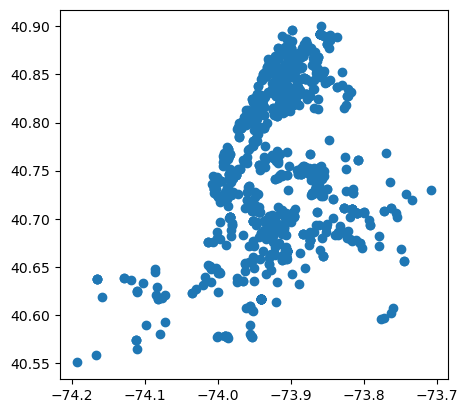

In [44]:
servicereq_geo.plot()

## 2.3 `offset` and `limit`
You may find that the issue with using this endpoint is that we are limited to 1000 rows per query. You will see the documentation refer to this as "pages" sometimes.


In [127]:
servicereq.shape

(1000, 32)

What to do? 

One way to get around this is to use the `limit` and `offset` parameters and a `for-loop` design to enable multiple queries. From the SODA documentation: 

>The `$offset` parameter is most often used in conjunction with $limit to page through a dataset. The `$offset` is the number of records into a dataset that you want to start, indexed at 0. For example, to retrieve the “4th page” of records (records 151 - 200) where you are using `$limit` to page 50 records at a time, you’d ask for an `$offset` of 150.

In [45]:
servicereq_url_offset = "https://data.cityofnewyork.us/resource/erm2-nwe9.json?$limit=50&$offset=150&$where=created_date between '2023-02-01T0:00:00.000' and '2023-03-01T0:00:00.000' and complaint_type='Noise - Residential' and descriptor='Loud Music/Party'".replace(" ", "%20")
servicereq_offset = pd.read_json(servicereq_url_offset)

This is now 50 entries of the "4th page".

So, to get all the data, what we can do is run a loop to change that offset amount iteratively. 

OR

If we are getting the data just once, we can use the filter function, accessible through `actions` ->  `Query Data` button on the dataset's home page. 

</figure>
<img src="https://raw.githubusercontent.com/wenzhengli-etal/UrbanDataScience_4680_5680/main/img/querydata.png" alt="drawing" width="1000" style="display: block; margin: 0 auto"/>
</figure>



### 2.3.1 A short review of loops

In [48]:
my_counter = list(range(0,1000,50))
print(my_counter)

[0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950]


In [137]:
# The for loop will iterate through each value in the list
# The {} is a placeholder for the value i in the list within a string
# .format(i) replaces {} with the current value of i, 
# allow dynamically inserting value i into the string output.
for i in my_counter:
    print("Current Counter is now at {}".format(i))

Current Counter is now at 0
Current Counter is now at 50
Current Counter is now at 100
Current Counter is now at 150
Current Counter is now at 200
Current Counter is now at 250
Current Counter is now at 300
Current Counter is now at 350
Current Counter is now at 400
Current Counter is now at 450
Current Counter is now at 500
Current Counter is now at 550
Current Counter is now at 600
Current Counter is now at 650
Current Counter is now at 700
Current Counter is now at 750
Current Counter is now at 800
Current Counter is now at 850
Current Counter is now at 900
Current Counter is now at 950


This might take a while to run and So let us focus on the first 200 records... :/

In [31]:
offset_list_smaller = list(range(0,200,50))

In [50]:
## I actually don't know what the upper range is for my dataset, but I will just use 100,000
# offset_list = np.arange(0,100000,50)

# I'm actually going to use a smaller list for demo and not overloading the API
# NumPy array is a more efficient, fixed-type structure optimized for numerical computations 
offset_list_smaller = np.arange(0,200,50)

list_of_dfs = []

for offset in offset_list_smaller:
    servicereq_url_offset = "https://data.cityofnewyork.us/resource/erm2-nwe9.json?$limit=50&$offset={}&$where=created_date between '2024-02-01T0:00:00.000' and '2024-03-01T0:00:00.000' and complaint_type='Noise - Residential' and descriptor='Loud Music/Party'".replace(" ", "%20").format(offset)
    servicereq_offset = pd.read_json(servicereq_url_offset)

    ## Here I am creating a list of dataframes by appending each dataframe to the list
    list_of_dfs.append(servicereq_offset)

I now have a list of 4 dataframes.

In [ ]:
len(list_of_dfs)

In [55]:
## pd.concat will concatenate the dataframes in the list
## to create a single dataframe
servicereq_final = pd.concat(list_of_dfs)

If I were to really try and get all this data, I'd put a `sleep()` call from the library `time` to pause my code from running the next line for a certain amount of time. 

In [147]:
import time

list_of_dfs = []

for offset in offset_list_smaller:
    servicereq_url_offset = "https://data.cityofnewyork.us/resource/erm2-nwe9.json?$limit=50&$offset={}&$where=created_date between '2023-02-01T0:00:00.000' and '2023-03-01T0:00:00.000' and complaint_type='Noise - Residential' and descriptor='Loud Music/Party'".replace(" ", "%20").format(offset)
    servicereq_offset = pd.read_json(servicereq_url_offset)

    ## Here I am creating a list of dataframes by appending each dataframe to the list
    list_of_dfs.append(servicereq_offset)
    
    ## I am adding a sleep timer to avoid overloading the API
    ## The sleep timer will pause the code for 10 seconds
    ## This gives me 10 seconds /run for each 50 records
    time.sleep(10)
    if servicereq_offset.shape[0] == 0:
        print("We are done")
        break

servicereq_final = pd.concat(list_of_dfs)

<div style="background-color:#d4edda; padding:10px; border-radius:5px;">

✅ **Note: Throttling and Application Tokens**
>How SODA handles throttling? You can make a certain number of requests without an application token, but they come from a shared pool and you’re eventually going to get cut off.
>
>If you want more requests, sign up for a Socrata account, then register for an application token and your application will be granted up to 1000 requests per rolling hour period. If you need even more than that, special exceptions are made by request. You can contact our support team here.
</div>


## In-class Exercise Q2 Querying and Concatenating 
- Using the [Film Permits](https://data.cityofnewyork.us/City-Government/Film-Permits/tg4x-b46p) dataset to retrieve two dataframes: 
    1. The **StartDateTime** should be after July 1, 2022
    2. The **StartDateTime** should be after July 1, 2022 & The **Category** should be `Television`. 
- Create a list of two dataframes with 50 rows per "page"
- Concatenate these two dataframes together into one dataframe
- Show the first 5 rows of the new dataframe.



Using the [Film Permits](https://data.cityofnewyork.us/City-Government/Film-Permits/tg4x-b46p) dataset to retrieve two dataframes: 
1. The **StartDateTime** should be after July 1, 2022
2. The **StartDateTime** should be after July 1, 2022 & The **Category** should be `Television`. 

In [ ]:
film_url1 = ## INSERT YOUR CODE HERE
film1 = pd.read_json(film_url1)

film_url2 = ## INSERT YOUR CODE HERE
film2 = pd.read_json(film_url2)

Concatenate these two dataframes together into one dataframe

In [ ]:
## INSERT YOUR CODE HERE

Show the first 5 rows of the new dataframe.


In [ ]:
## INSERT YOUR CODE HERE